# To-dos (13/11/23)

1. Remove fits to log, only use fit_short
2. Investigate the bad fits for the slices 
3. Confirm that the mcmc really does work for the entire fit
4. Plot the curve using [a, b, c, d] and play around with these values
5. Fix d = 0.5, and add "error parameters" for the temperature (eT + f) 
6. Run mcmc for this starting from e = 1, f = 0
7. Just use the entire series as your fit function

In [1]:
import emcee as mc #try markov chain monte carlo

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import data_analysis_script as da
import importlib as im
from scipy.optimize import curve_fit, minimize
import emcee as mc #try markov chain monte carlo

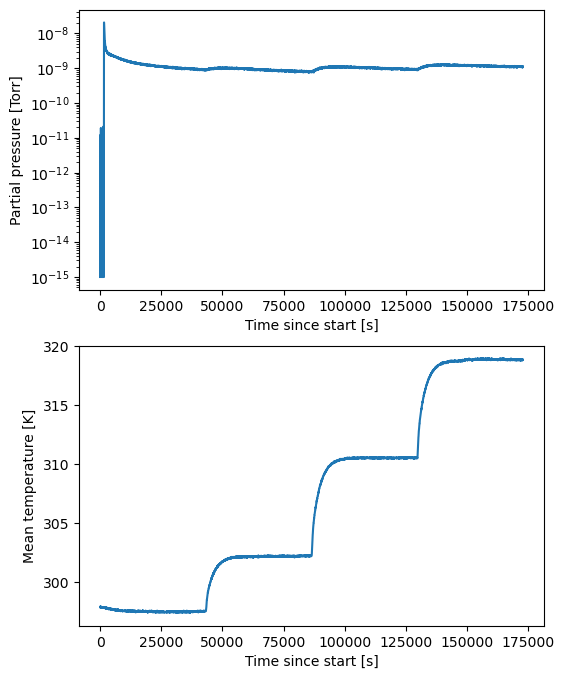

In [3]:
from data_analysis_script import Dataset
run_label = '2023-11-06' ## Change this to look at different runs
d = Dataset(run_label=run_label, gases=['O2'])
d.GetData()
d.PlotSingleGas('O2')

In [4]:
time = np.array(d.data['O2']['Exposure_time'])
temp = np.array(d.data['O2']['Mean_temp']) #['Mean_temp'])
p = np.array(d.data['O2']['Partial_pressure'])

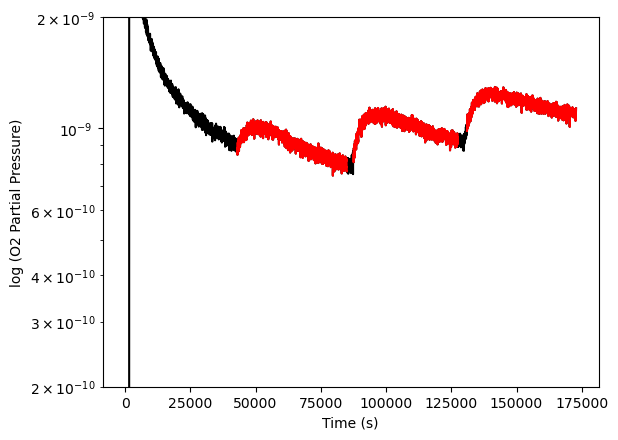

In [5]:
time_slices = [[43000, 85000],
               [87500, 127500],
               [131000, 175000]]

plt.semilogy(time, p, 'k') # Plot the logarithm (base 10) of the partial pressure of O2 (oxygen) against time. 
plt.ylabel('log (O2 Partial Pressure)') 
plt.xlabel('Time (s)')

for ts in time_slices:
    gpts = (time > ts[0]) & (time < ts[1])
    plt.semilogy(time[gpts], p[gpts],'r')
plt.ylim(2e-10, 2e-9)
#plt.xlim(12e4, 14e4)
plt.show()

# MCMC

In [6]:
def combined_chisq_short(params, data_list, y):
    ds = Dataset("","")
    ndsets = len(data_list)

    a, b, c, e, f = params[0], params[1], params[2], params[3], params[4]


    tot_chisq = 0
    sig = 0.5e-9 ## error on values
    e_err = 0.1
    f_err = 1
    

    for n in range(ndsets):
        cdat = data_list[n]
        cy = y[n]
        curr_chisq = np.sum(((d.fitfunction_short_temp_offset(cdat, a, b, c, e, f) - cy)/sig)**2) + ((e - 1)/(2*e_err))**2 + ((f - 0)/(2*f_err))**2
        if(not np.isnan(curr_chisq)):
            tot_chisq += curr_chisq
        else:
            tot_chisq += np.inf

    print(tot_chisq)
    return tot_chisq

time_slices = [[43000, 85000],
               [87500, 127500],
               [131000, 175000]]
tT = []
y = []
combined_data = []
for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT.append((np.vstack((time[gpts], temp[gpts]))))
    y.append(p[gpts])
    combined_data.append([time[gpts], p[gpts]])

In [7]:
spars = np.array([5e-3, 6000, 0, 1, 0])
print(combined_chisq_short(spars, tT, y))
res = minimize(combined_chisq_short, spars, args=(tT, y), method='Nelder-Mead', options={"maxiter": 10000})

134.87696557819754
134.87696557819754
134.87696557819754
106.4856829218024
2992.360415196208
134.8769660868769
4845.986760874873
134.86716938728
4791.85361514231
2164.3789295124325
2531.766847928473
323.03017602147276
4311.5729778563145
725.0167184867698
975.6071186782485
278.12570569959956
628.0587492560444
124.49059230230554
202.2765483027944
121.08853632185613
128.4035238335598
183.8059011373953
110.57808613571612
211.76922953850726
109.40120900647617
112.94375485106175
125.16438011223975
110.9513727106121
127.63170887446311
109.62838804388798
114.94912156557488
108.17080958283086
113.06737512618761
107.60138595988677
111.16985321555941
107.652483874165
110.710590111904
107.33794289148
109.18952373712108
107.25938746328109
110.55546754988053
106.83731540864162
110.46530765141266
106.72282082200734
105.882121543611
105.36451116325895
105.25471384806004
104.61929305715034
105.81700066842345
103.9791044098611
102.64262887662954
102.49015476042256
100.71207214519822
105.24372131661565
1

In [8]:
print(res.x)

[ 1.29646105e-01  7.99648160e+03  1.11798123e-01  9.99999772e-01
 -3.75665461e-03]


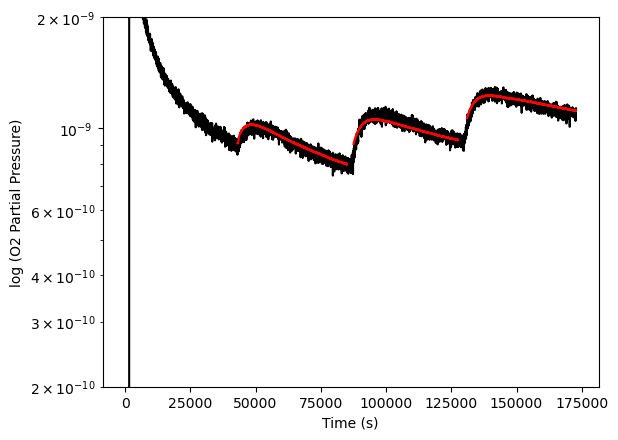

In [9]:
plt.figure()
plt.semilogy(time, p, 'k') # Plot the logarithm (base 10) of the partial pressure of O2 (oxygen) against time. 
for i in range(len(combined_data)):
    plt.plot(combined_data[i][0], np.abs(d.fitfunction_short_temp_offset(tT[i], *res.x)), 'r')
plt.ylabel('log (O2 Partial Pressure)') 
plt.xlabel('Time (s)')

plt.ylim(2e-10, 2e-9)

plt.show()

In [10]:
print(res.x)

[ 1.29646105e-01  7.99648160e+03  1.11798123e-01  9.99999772e-01
 -3.75665461e-03]


bp: [ 4.69385803e+00  9.05230053e+03  1.61039742e+00  8.98370962e-01
 -2.42972474e+00]
bp: [ 3.58837271e+01  1.03722017e+04 -2.41118915e+04  1.01423821e+00
 -3.61772019e+01]
bp: [ 1.42669294e-04  1.43988336e+03 -4.19138279e+04  1.19503824e+00
 -2.58830385e+02]
14.267852062578786
14.267852062842728
14.267852062578873
14.267852062576122
14.267852063277413
14.267852062575667
5130.214721578208
5130.213565632286
5130.214721796175
5130.214721578864
5130.212892762786
5130.214715703137
14.267852062767512
14.267852062577827
14.267852062767723
14.267852062764849
14.267852062710922
14.26785206276201
14.267852062579657
14.267852062763502
14.267852062579736
14.267852062576996
14.267852063145124
14.267852062576054
14.267852062577916
14.267852062823804
14.267852062577848
14.267852062575255
14.267852063246695
14.267852062574637
14.267852062578225
14.267852062783167
14.267852062578228
14.267852062575564
14.267852063178678
14.2678520625748
14.267852062578164
14.267852062783101
14.267852062578132
14.2678

(1000.0, 190000.0)

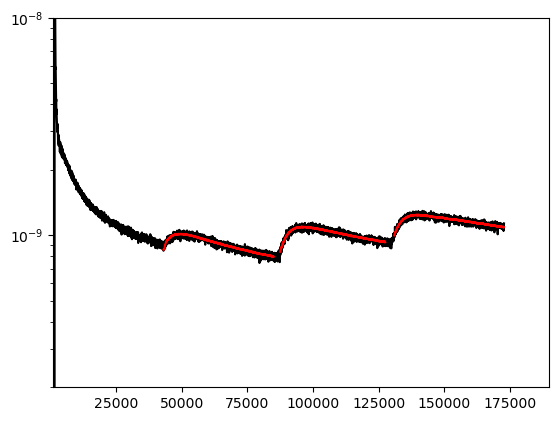

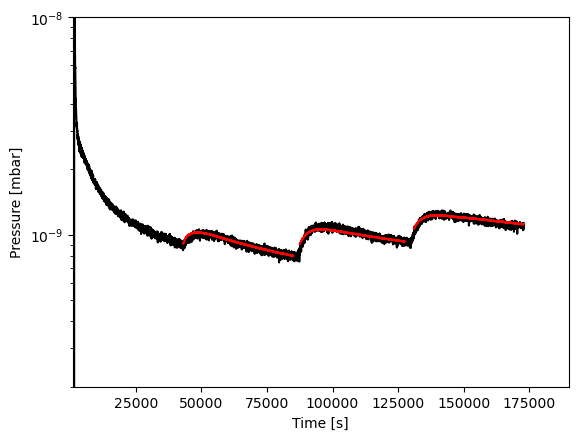

In [11]:
#Plotting Code

time_slices = [[43000, 85000],
               [87500, 127500],
               [131000, 175000]]

#Plot with different fit parameters for each time slice

plt.figure()
plt.semilogy(time, p, 'k')

for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT = np.vstack((time[gpts], temp[gpts]))
    y = p[gpts]
    spars = [1.29648471e-01, 7.99649264e+03, -1.11283810e-01, 9.99999525e-01, -3.72000013e-03]
    #spars = [3.48859880e-09, -3.45969798e+01, 3.98032858e-01, 1, 0]
    #Spars that work for curvefit: 3.48859880e-09, -3.45969798e+01, 3.98032858e-01, 1, 0
    #Spars from old teflon data: 3.48859880e-09, 3.45969798e+03, 3.98032858e-01, 1, 0
    #res = minimize(combined_chisq_short, spars, args=(combined_data), method='Nelder-Mead')
    #bp = res.x
    bp, bc = curve_fit(d.fitfunction_short_temp_offset, tT, y, p0=spars, method='lm', maxfev=90000)
    plt.plot(tT[0], d.fitfunction_short_temp_offset(tT,*bp),'r')
    print('bp:', bp)
    plt.ylim(2e-10, 1e-8)
    plt.xlim(1e3, 19e4)
    #res = minimize(combined_chisq_short, spars, args=(combined_data,))
    #bp = res.x

#Plot with the same fit parameters for all time slices
tT = []
y = []
combined_data = []
plt.figure()
plt.semilogy(time, p, 'k')
for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT.append((np.vstack((time[gpts], temp[gpts]))))
    y.append(p[gpts])
    combined_data.append([time[gpts], p[gpts]])
spars = [1.29648471e-01, 7.99649264e+03, -1.11283810e-01, 9.99999525e-01, -3.72000013e-03]
#spars = [7.08859880e-05, 3.45969798e+03, 1.28032858e+03, 1, 5]
#bp, bc = curve_fit(d.fitfunction_short_temp_offset, np.vstack((time,temp)), p, p0=spars, method='lm', maxfev=90000)
res = minimize(combined_chisq_short, spars, args=(tT, y))
bp = res.x

for j in range(len(time_slices)):
    tvals = combined_data[j][0]
    plt.plot(tvals, d.fitfunction_short_temp_offset(tT[j], *bp), 'r')
    

print('bp:', bp)

plt.ylabel('Pressure [mbar]')
plt.xlabel("Time [s]")
plt.ylim(2e-10, 1e-8)
plt.xlim(1e3, 19e4)


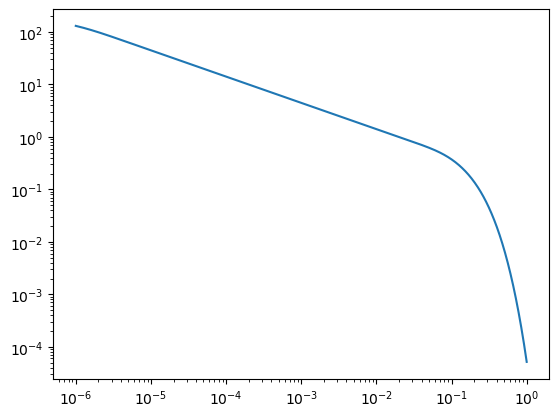

In [12]:
tvec = np.logspace(-6,0,1000)

maxn = 200

fval = np.zeros_like(tvec)
for n in range(maxn):
    fval += np.exp(-(np.pi*(2*n+1))**2*tvec)

plt.figure()
plt.loglog(tvec, fval)

In [ ]:
nwalkers, ndim = 100, 5

ffn = lambda p,d,y: -combined_chisq_short(p,d, y)

scaling_factors = np.array([1e-1, 7e+3, 1e-1, 9.9e-1, 3.7e-3])
p0 = [spars + scaling_factors*0.001*np.random.randn(ndim) for i in range(nwalkers)]

sampler = mc.EnsembleSampler(nwalkers, ndim, ffn, args=(tT,y))
sampler.run_mcmc(p0, 4000, progress=True)

14.343791216144435
14.712113304208712
15.617261670704709
15.307805783506184
14.403643553035593
19.038131385311633
15.616099936307434
15.787193316146706
14.388586562257416
16.264660592536583
19.32984857664727
15.738625358040549
19.506424893863354
14.28440411190929
18.833836881585192
23.699469286016996
19.234163094144336
25.862228503485596
33.14877260854803
15.37970004970139
15.509236361334324
94.36536793232293
16.844663656145176
15.147703605965354
49.030824182121904
18.608865644678843
24.213625884163687
14.588820521964784
14.354704607631886
14.322864665456885
15.438740022726044
18.024456168494762
23.42561167556504
27.46029656809154
30.570454261868576
14.614337602521957
16.58525950941041
14.582529285088937
14.27048047444319
17.303195123067503
14.585836508895465
31.977446661274833
20.82306782555615
35.47503223006635
16.19164252774245
14.326644230535091
14.764998454587992
14.288429451204966
43.80610219258743
14.98413201467077
41.984830021790785
14.757309953294964
29.42019115188431
19.74961

  0%|          | 4/4000 [00:00<01:40, 39.85it/s]

14.666149962793824
16.283081628419964
16.336969884784757
77.63258148558384
26.171224803638133
22.035880475791412
26.14022024244521
15.430836722921985
14.2856182668661
20.176107208682254
40.247367489031326
86.4949811159733
14.812875516796023
14.599421294113615
138.10343441414193
26.754757251545854
14.268901870520093
17.12353546034346
30.925415777082044
17.714014415555386
42.03321402260791
14.569109573918109
16.079884959484637
18.259847910771043
15.446916495629859
14.489259713783238
90.03189237267861
14.715485164512257
93.29800067704787
26.350288695689514
16.399641439298506
26.849749702168243
15.264176645470048
17.38879718330433
14.385903506019517
14.268791942471225
18.137183711585838
18.062832068205495
20.341100357080748
29.59307008989704
16.269717132957304
21.180773237197943
19.411905478860934
26.760313701135484
50.256778013955376
25.283966759409434
29.46180423394427
15.044839453589722
16.314475182834933
16.796617385658788
14.333317926357951
14.47118235579072
14.465663164395659
20.4912

  0%|          | 8/4000 [00:00<01:42, 39.12it/s]

17.574777068903593
14.381640348962755
15.667786738852914
18.331559902130643
15.74720448092193
17.122605406209274
15.342351546917527
15.188010917548716
16.98699834846986
19.279698684370153
23.191402464013954
14.805449256821095
16.600012866098982
14.61848740924306
22.91956208367172
16.502974898722396
14.718094307920817
30.76812588143062
15.126287555724463
14.769538271227178
17.46608915614442
16.341749150412376
15.026042303929039
16.017634600717564
17.17648779599198
26.027208241534943
14.594069546155996
14.67176920197689
14.472252837714104
16.610036884811848
28.26683730040547
39.58465963291394
16.637218942232387
22.352546302262255
15.338222733743567
15.195811786057359
23.925639525805266
20.236027160397025
14.605353726229197
14.535975370315064
16.607719753084233
16.614335325592556
17.164038746567083
16.853623511882926
17.466494308071486
16.354842964920778
18.164816366908255
16.59866416375426
15.537379696726113
15.393442180488528
17.51704960059821
24.235171572982335
16.25267218852526
26.301

...

 36%|███▌      | 1447/4000 [00:36<01:04, 39.84it/s]

934.3763181357908
378.75794988918426
16.0609770729438
27.857286367725955
22803.28002853141
116.04355135196681
19.43058053922156
30.68118200539577
23.822318061712508
18.281371906571188
15.77288344672995
16.221167490854455
109.72842607923306
16.87970709450304
30.999060095040747
14.59691441926974
82.91484304623494
26.26843752140736
94.64656936643351
167.74805088964473
409.2011457187871
34.41119870587107
14.456600253958044
16.63499877075062
16.289962032786303
16.86320902864785
19.65588296792676
19.363699763666737
17.58883338399595
63.26021130029408
15.829610324378748
49.76657885778792
27.484422000226253
57.65534461016409
15.688166009447603
22.70662793991517
180.4603563500895
15.965038069890392
53.648996785054315
17.92952982233725
122.39564763950277
3944.1348904572405
17.060048294950967
16.716759122136622
22.068186293864134
17.3061124287038
15.82960331222058
14.142404296580057
17.371990603260233
15.425913115055277
17.095514842917073
19.432368542166977
27.887753623691236
52.393543021042916
1

 36%|███▋      | 1455/4000 [00:36<01:05, 39.04it/s]

14.918067799844252
652.4307629327401
100.96779776929725
15.698100899300222
601.9408976135028
25.33162422813489
543.1385387219419
15.52373178457984
225.15990871536297
15.854568292401897
1107.7968780518097
15.556783939543218
15.886269560671163
1901.5135865037844
20.59133416802719
6407.170752483144
17.25852952518374
39.004274192856556
20.28683519588864
49.37210836839206
760.4210690464929
14.691138734047852
166.05090642861833
58.23731551192843
6466.505947846257
17.798640536898354
16.371815975704752
36.16014976807911
17.744177723473914
94.14943456199103
15.154582897341701
789.5987801042343
355.092163493776
243.88343179694823
570.5296268335017
1735.9617566328752
41.20304380591024
15.510217751875778
82.15712597936638
36.14069392455687
92.79025790167809
17.004127462108762
95.51390134631859
692.8810463775396
21.075056477082853
20.76899082585373
337.5110144442843
4645.34923619139
24.95133414724865
15.985227495265345
15.14142990175187
17.595790961136185
14.781311905463713
137.4829509937909
19.120

 36%|███▋      | 1459/4000 [00:36<01:04, 39.18it/s]

In [ ]:
# Extract the chain of samples
samples = sampler.get_chain()

# Calculate the median of each parameter across all walkers and steps
median_params = np.median(samples, axis=(0, 1))

# Print the median parameters
print("Median parameters:", median_params)
print('P0:', p0)

In [ ]:
fig, axes = plt.subplots(5, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["a", "b", "c", "e","f"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [ ]:
import corner

flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)
print(flat_samples.shape)

fig = corner.corner(flat_samples, labels=labels)

In [ ]:
plt.figure()
plt.semilogy(time, p, 'k')
tT_final = []
for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT_final.append((np.vstack((time[gpts],temp[gpts]))))
inds = np.random.randint(len(flat_samples), size=10)
for ind in inds:
    sample = flat_samples[ind]
    for j in range(len(time_slices)):
        tvals = combined_data[j][0]
        plt.plot(tvals, d.fitfunction_short_temp_offset(tT_final[j], sample[0], sample[1], sample[2], sample[3], sample[4]), 'r', alpha=0.5)

plt.ylim(6e-10, 6e-9)
plt.ylabel('Pressure [mbar]')
plt.xlabel("Time [s]")

In [ ]:
from IPython.display import display, Math

CI = 10 ## L/s
Area = 0.01 ## m^2
mbar_to_Pa = 100
K = 0.22
p_atm = 1.01e5 #Pa
m_to_cm = 100
L_to_m3 = 1e-3

mcmc_D0 = np.percentile((flat_samples[:, 0]*CI*mbar_to_Pa*L_to_m3/(K*p_atm*Area) * m_to_cm)**2, [16, 50, 84])
mcmc_Ea = np.percentile(flat_samples[:, 1], [16, 50, 84])

print("D0 [cm^2/s]: ", mcmc_D0)
print("Activation energy [K]: ", mcmc_Ea)